# TRPL decay curves — smoothing

We load the example TRPL sweep and apply a Savitzky-Golay smoothing to the decay curves. Smoothing is applied here in the notebook, on top of the loader's `best_decays` (raw counts, or pre-pulse background-subtracted counts when `bg_region_ns` is given) — it is not something the loader itself does, since a correction that alters the data is opt-in and left to the caller (see `ACTRPLSweep`'s design).

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import numpy as np
import leman as tmdc
from leman import fitting, processing, plotting

## Locating the laser spot

Before looking at the decays, we find the laser spot on the sample. `ACLaserRefImg` fits the spot's centre and 1/e² radius from a dedicated laser-spot image; `show_image(laser_annotation=True)` draws that fitted boundary directly on the image it was fitted from.

ACLaserRefImg
  File                  : ./data/TRPL/laser_spot_26_07_31_09_29_25.csv
  Center                : (270.4, 224.3) px
  Estimated 1/e² Radius : 4.9 px
  Estimated 1/e² Diameter: 9.7 px


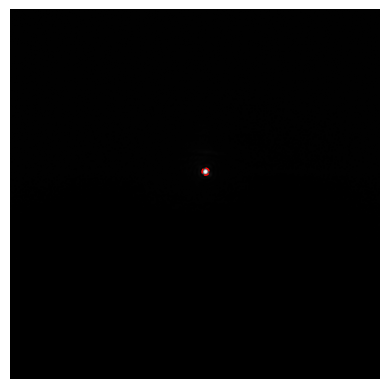

In [2]:
laser_ref = tmdc.loaders.ACLaserRefImg("./data/TRPL/laser_spot_26_07_31_09_29_25.csv")

fig, ax = laser_ref.show_image(laser_annotation=True)
print(laser_ref)

Next we place that fitted spot on a white-light image of the sample, taken separately so the flake and contacts are visible. `ACSampleImg` takes the same `laser_ref`, so the boundary drawn here is the identical fit — not a second detection on this image.

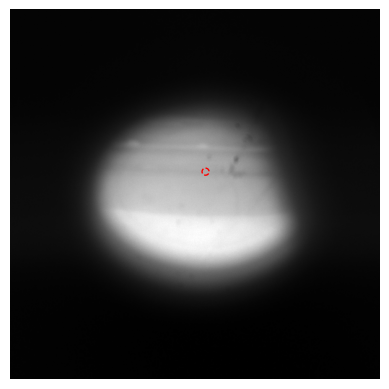

In [3]:
sample_image = tmdc.loaders.ACSampleImg(
    "./data/TRPL/wl_ref_26_07_31_13_51_44.csv",
    laser_ref=laser_ref,
)

fig, ax = sample_image.show_image(laser_annotation=True)

## Locating the shifted spots (`right1`, `right2`)

Each `*_...csv` white-light image is taken with the excitation spot moved to a new galvo position. Overlaying the original `laser_ref` (fitted above) shows where the spot *used* to be; fitting each image itself with the same `ACLaserRefImg` class — built to handle a white-light background — gives where it *is now*. Both positions are listed in `shifted_images` below, so a third position later is just another dict entry.

ACLaserRefImg
  File                  : ./data/TRPL/right_spots/right1_26_07_31_13_54_16.csv
  Center                : (289.2, 228.1) px
  Estimated 1/e² Radius : 24.0 px
  Estimated 1/e² Diameter: 48.1 px


ACLaserRefImg
  File                  : ./data/TRPL/right_spots/right2_26_07_31_13_57_12.csv
  Center                : (305.4, 229.9) px
  Estimated 1/e² Radius : 24.2 px
  Estimated 1/e² Diameter: 48.4 px


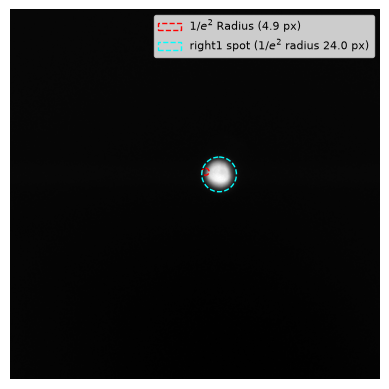

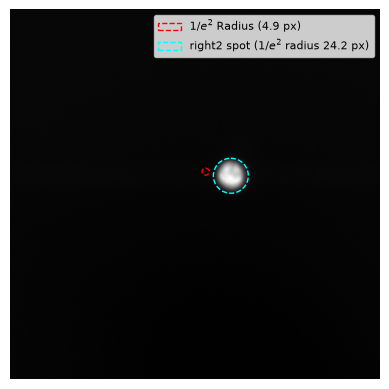

In [4]:
shifted_images = {
    "right1": "./data/TRPL/right_spots/right1_26_07_31_13_54_16.csv",
    "right2": "./data/TRPL/right_spots/right2_26_07_31_13_57_12.csv",
}

shifted_spots = {}
for name, path in shifted_images.items():
    sample = tmdc.loaders.ACSampleImg(path, laser_ref=laser_ref)
    spot = tmdc.loaders.ACLaserRefImg(path)
    shifted_spots[name] = spot

    fig, ax = sample.show_image(laser_annotation=True)
    ax.add_patch(Circle(
        (spot.center_x, spot.center_y), spot.radius,
        edgecolor="cyan", facecolor="none", linewidth=1, linestyle="--",
        label=f"{name} spot ($1/e^2$ radius {spot.radius:.1f} px)",
    ))
    ax.legend(loc="upper right", fontsize=8)
    print(spot)

## Spot displacement

Neither image carries a pixel-to-micrometre scale on its own — that comes from the laser spot's known physical diameter (1.2 µm), which fixes what `laser_ref`'s fitted diameter in pixels corresponds to. The same scale then converts the pixel distance between `laser_ref` and each shifted spot's fitted centre (`right1`, `right2`) into micrometres.

In [5]:
laser_diameter_um = 1.2
pixel_scale = laser_diameter_um / (2 * laser_ref.radius)  # um / px

print(f"Pixel scale : {pixel_scale:.4f} um/px")

distance_um = {}
for name, spot in shifted_spots.items():
    dx = spot.center_x - laser_ref.center_x
    dy = spot.center_y - laser_ref.center_y
    distance_px = np.hypot(dx, dy)
    distance_um[name] = distance_px * pixel_scale
    print(f"{name:>7s} separation : {distance_px:.2f} px = {distance_um[name]:.3f} um")

Pixel scale : 0.1232 um/px
 right1 separation : 19.13 px = 2.357 um
 right2 separation : 35.47 px = 4.369 um


## Load the sweep

The example directory holds a 3-point field sweep (`V_A`/`V_B` anti-correlated) plus its metadata companion; `ACTRPLSweep` classifies them by content, not filename. The same directory also holds an instrument-response file (`prefix="TRPL_"` keeps it out of the sweep — see below), so without the prefix the loader would fold it in as a spurious fourth sweep point.

`gates={"top": "V_A", "bottom": "V_B"}` is passed explicitly — the electrodes can be wired either way round and no export records which, so the loader never assumes it (see `ACTRPLSweep`'s docstring). This matches the wiring already recorded for this exact dataset in `tests/test_loaders_trpl.py`; a different session's data needs its own confirmed mapping, not this one copied over.

In [6]:
scan = tmdc.loaders.ACTRPLSweep(
    "./data/TRPL/", prefix="TRPL_", gates={"top": "V_A", "bottom": "V_B"},
)
print(scan)

ACTRPLSweep — 3 sweeps × 3205 time bins  [Time-resolved photoluminescence]
  File        : ./data/TRPL/
  Time range  : 0 – 12.82 ns (4 ps bins)
  Sweep       : not declared — sweep index used as the axis
  Gates       : dual-gate, anti-correlated (field-like)  (top ← 'V_A', bottom ← 'V_B')
  Power       : 147.7 → 147.9 µW
  Varying     : V_A, V_B, I_B, I_A
  Files       : 3 per-point files
  Companion   : TRPL_26_07_30_16_30_11_iter_0.csv
  Peak counts : 18



## Instrument response function

`IRF_..._iter_3.csv` is the detector's response to the excitation pulse itself, measured separately from any sample decay. Its header has the same `[Par, Wavelength, Exp]` temporal block layout as a TRPL decay, so it loads with the same class — as a single file, i.e. a one-point sweep (`n_sweeps == 1`).

In [7]:
irf = tmdc.loaders.ACTRPLSweep("./data/TRPL/IRF_26_07_30_18_44_26_iter_3.csv")
print(irf)

ACTRPLSweep — 1 sweep × 3205 time bins  [Time-resolved photoluminescence]
  File        : ./data/TRPL/IRF_26_07_30_18_44_26_iter_3.csv
  Time range  : 0 – 12.82 ns (4 ps bins)
  Sweep       : not declared — sweep index used as the axis
  Gates       : gates static  — wiring not declared; pass gates={'top': ..., 'bottom': ...} for v_top/v_bot/E_F
  Power       : 0.0 → 0.0 µW
  Peak counts : 15184



## Raw decays

`scan.best_decays` has shape `(n_bins, n_sweeps)` — one decay per column, sharing `scan.time`. The sample decays (peak counts ~15-20) and the IRF (peak counts ~15000) sit on completely different scales, so each curve below is min-max normalised to its own range rather than sharing one absolute counts axis. Each sweep point is labelled with the gate voltages actually applied (`V_top`/`V_bot`) rather than a bare sweep index.

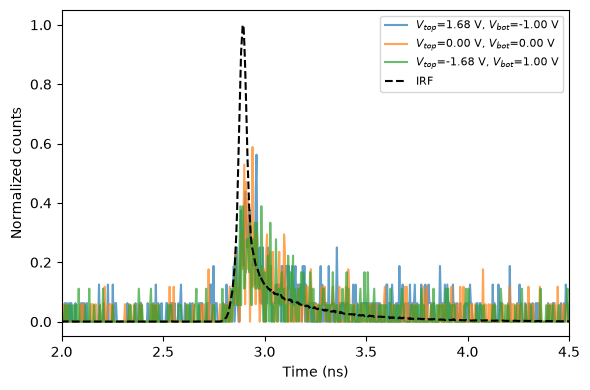

In [8]:
decays_norm = processing.normalise_minmax(scan.best_decays)
irf_norm = processing.normalise_minmax(irf.best_decays)

fig, ax = plt.subplots(figsize=(6, 4))

for i in range(scan.n_sweeps):
    ax.plot(scan.time, decays_norm[:, i], alpha=0.7,
            label=f"$V_{{top}}$={scan.v_top[i]:.2f} V, $V_{{bot}}$={scan.v_bot[i]:.2f} V")
ax.plot(irf.time, irf_norm[:, 0], "k--", label="IRF")

ax.set_xlabel(scan.axis_label)
ax.set_ylabel("Normalized counts")
ax.set_xlim(2, 4.5)
ax.legend(fontsize=8)
fig.tight_layout()

## Smoothing

`processing.smooth_savgol` runs a Savitzky-Golay filter along a chosen axis. `best_decays` is `(n_bins, n_sweeps)`, so `axis=0` filters each decay along time independently — no mixing between the three sweep points. This is the same function already used for spectral smoothing elsewhere in the package; `window` must be odd and `>` `poly_order`.

In [9]:
smoothed_decays = processing.smooth_savgol(
    scan.best_decays,
    window=11,
    poly_order=3,
    axis=0,
)

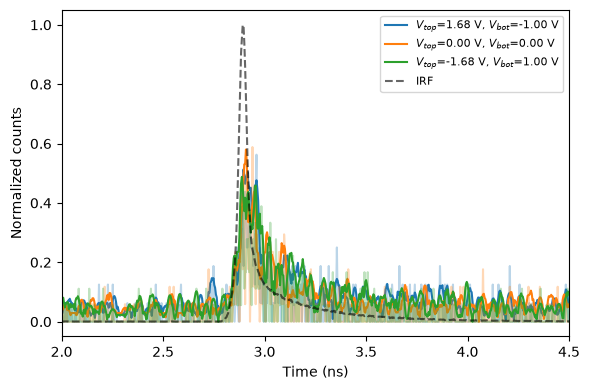

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
smoothed_norm = processing.normalise_minmax(smoothed_decays)
for i in range(scan.n_sweeps):
    ax.plot(scan.time, decays_norm[:, i], color=colors[i % len(colors)], alpha=0.3)
    ax.plot(scan.time, smoothed_norm[:, i], color=colors[i % len(colors)],
            label=f"$V_{{top}}$={scan.v_top[i]:.2f} V, $V_{{bot}}$={scan.v_bot[i]:.2f} V")
ax.plot(irf.time, irf_norm[:, 0], "k--", label="IRF", alpha=0.6)

ax.set_xlabel(scan.axis_label)
ax.set_ylabel("Normalized counts")
ax.set_xlim(2, 4.5)
ax.legend(fontsize=8)
fig.tight_layout()

A Savitzky-Golay filter can drive a decay negative in its noisy tail — a polynomial fit through a near-zero, noisy region can dip below it. On this linear axis that shows up directly as the smoothed curve visibly crossing below zero rather than being hidden by a log scale. If negative points matter downstream — e.g. before fitting — check `(smoothed_decays < 0).sum(axis=0)` rather than assuming the plot shows everything.

`window`/`poly_order` are a judgment call, not a default this package picks: a wider window smooths more but can flatten a fast initial decay; too high a `poly_order` under-smooths. `processing.smooth_median` is the alternative — a median filter, more aggressive on isolated spikes but with no polynomial ringing — pass `kernel=(k, 1)` if you use it here so it does not average across the three sweep columns.

## `right1` / `right2` decays vs. the IRF

`right1` and `right2` each have their own TRPL decay file — a single spot's acquisition, not part of the 3-point field sweep loaded above — loaded the same way as `irf`, as a one-point `ACTRPLSweep`. Comparing them alongside the IRF, each min-max normalized to its own local range within the plotted window, shows how the decay shape itself changes between the two shifted positions. As in the smoothing section above, the raw trace is drawn faintly behind its Savitzky-Golay-smoothed curve.

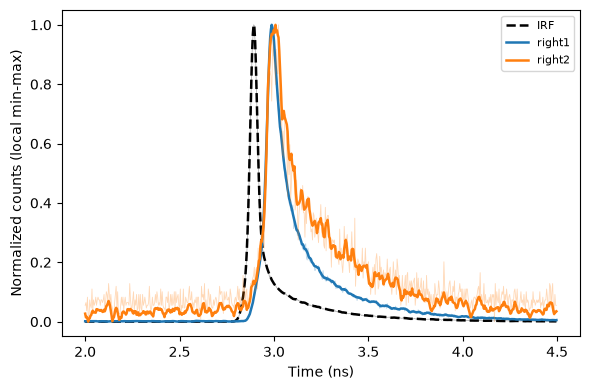

In [11]:
shifted_decay_paths = {
    "right1": "./data/TRPL/right_spots/right1_26_07_31_13_56_29_iter_3.csv",
    "right2": "./data/TRPL/right_spots/right2_26_07_31_14_04_33_iter_3.csv",
}
shifted_decays = {
    name: tmdc.loaders.ACTRPLSweep(path)
    for name, path in shifted_decay_paths.items()
}

T_MIN_NS, T_MAX_NS = 2.0, 4.5  # around the pulse, well before the ~7.6 ns afterpulse artifact


def smoothed_in_window(sweep):
    # Smooth over the full time axis first, then window only for the plot --
    # smoothing an already-cropped slice would let the filter's edge handling
    # distort exactly the window boundaries being plotted.
    smoothed = processing.smooth_savgol(sweep.best_decays[:, 0], window=11, poly_order=3)
    mask = (sweep.time >= T_MIN_NS) & (sweep.time <= T_MAX_NS)
    return sweep.time[mask], sweep.best_decays[mask, 0], smoothed[mask]


fig, ax = plt.subplots(figsize=(6, 4))

t_irf, irf_raw, irf_smoothed = smoothed_in_window(irf)
ax.plot(t_irf, processing.normalise_minmax(irf_raw), color="black", lw=0.6, alpha=0.3)
ax.plot(t_irf, processing.normalise_minmax(irf_smoothed), color="black", lw=1.8, ls="--", label="IRF")

for name, sweep in shifted_decays.items():
    t, raw, smoothed = smoothed_in_window(sweep)
    line, = ax.plot(t, processing.normalise_minmax(raw), lw=0.6, alpha=0.3)
    ax.plot(t, processing.normalise_minmax(smoothed), color=line.get_color(), lw=1.8, label=name)

ax.set_xlabel(scan.axis_label)
ax.set_ylabel("Normalized counts (local min-max)")
ax.legend(fontsize=8)
fig.tight_layout()

## Sparse lifetime fitting

**This fitting approach is still in testing** — the rise/decay recovery is sensitive to `alpha` and to the fit window width (see the caveats below and in the following cells), and neither has been validated as a stable default across datasets yet. Treat results from this section as provisional, not as a finished analysis method.

`tmdc.fitting.fit_sparse_lifetime` fits a decay against a broad, log-spaced grid of candidate lifetimes, each convolved with the measured IRF, with an L1 (Lasso) penalty keeping only as many of them active as the data can support. Coefficients are signed — positive for decay, negative for rise — so one fit recovers both without assuming ahead of time how many exponential components are present. See the function's own docstring for the full mechanism; it is adapted from the rise-time analysis in Tagarelli et al. (SI Section 5, "Time resolved photoluminescence fitting").

`fitting.build_irf_kernel` turns the `irf` sweep loaded above into the convolution kernel the fit needs, resampled onto the same 4 ps bin spacing as `scan`. The fit is restricted to a short window around the pulse arrival (`t0`, taken as the IRF's own peak time) — well before the periodic afterpulse structure visible in the very first plot of this notebook, and short enough that a candidate lifetime near `tau_grid`'s upper edge stays clearly distinguishable from a flat offset (see the function's docstring for why that matters).

`fitting.fit_scan_lifetime` wraps this per sweep of an `ACTRPLSweep` -- windowing, normalizing, and fitting each one with an identical dictionary -- and works the same way whether the sweep has many points (`scan` below) or just one (`right1`/`right2` further down): a single-file sweep is simply the `n_sweeps == 1` case of the same object.

In [12]:
t0 = irf.time[np.argmax(irf.best_decays[:, 0])]
dt = np.median(np.diff(scan.time))
kernel = fitting.build_irf_kernel(irf.time, irf.best_decays[:, 0], dt=dt)

T_MIN_RISE_NS, T_MAX_RISE_NS = -0.2, 1.3
n_window_points = ((scan.time - t0 >= T_MIN_RISE_NS) & (scan.time - t0 <= T_MAX_RISE_NS)).sum()

print(f"t0 = {t0:.4f} ns, dt = {dt * 1e3:.2f} ps, window has {n_window_points} points")

t0 = 2.8922 ns, dt = 4.00 ps, window has 374 points


`alpha` was checked across a small grid on this dataset (`3e-4` to `2e-2`). Below `1e-3` the rise component keeps splitting across 2-4 candidate lifetimes with a wide amplitude-weighted spread — a noisier, less stable estimate. At `1e-3` every sweep still has an active rise component (the zero-field sweep splits into two, flagged by its nonzero `tau_rise_err`; the other two settle on one). Above roughly `1.5e-3` the rise term disappears for at least one sweep and the fit collapses onto decay alone. `1e-3` is used below as the last value before that collapse — the same selection logic as the source analysis, just at a different value, because this dataset's peak counts (~16-18, versus a few hundred in the dataset the method was developed on) make the fit considerably more sensitive to `alpha`. Treat the rise times below as illustrating the method rather than a precision measurement; the fitted decay lifetimes (1-1.7 ns) are comparable to the fit window's own width (1.5 ns) and are reported for completeness, not as a well-constrained decay time.

In [13]:
ALPHA = 1e-3  # tuned for this dataset's low photon counts -- see markdown above

lifetime_results = fitting.fit_scan_lifetime(
    scan, t0, kernel, t_range=(T_MIN_RISE_NS, T_MAX_RISE_NS), alpha=ALPHA,
)

for i, result in enumerate(lifetime_results):
    print(f"V_top={scan.v_top[i]:+.2f} V, V_bot={scan.v_bot[i]:+.2f} V")
    print(result)
    print()

V_top=+1.68 V, V_bot=-1.00 V
SparseLifetimeResult
  Rise         : 0.1354 ± 0 (1 component(s))
  Decay        : 1.41 ± 0.088 (2 component(s))
  alpha        : 0.001
  Residual std : 0.1398

V_top=+0.00 V, V_bot=+0.00 V
SparseLifetimeResult
  Rise         : 0.04352 ± 0.063 (2 component(s))
  Decay        : 1.663 ± 0.14 (3 component(s))
  alpha        : 0.001
  Residual std : 0.1277

V_top=-1.68 V, V_bot=+1.00 V
SparseLifetimeResult
  Rise         : 0.1354 ± 0 (1 component(s))
  Decay        : 1.038 ± 0.048 (2 component(s))
  alpha        : 0.001
  Residual std : 0.176



Data vs. fitted model, in the rise-time window:

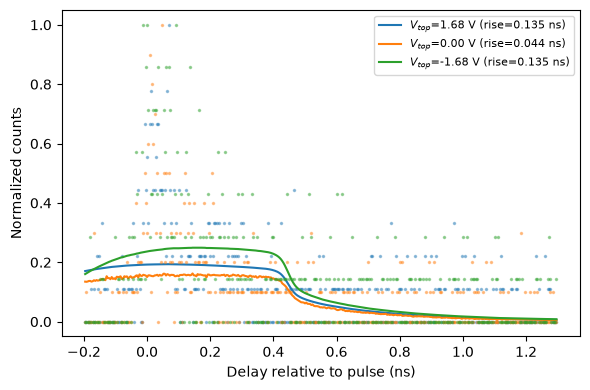

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))

for i, result in enumerate(lifetime_results):
    line, = ax.plot(result.t, result.y, ".", ms=3, alpha=0.4)
    ax.plot(result.t, result.y_fit, "-", color=line.get_color(),
            label=f"$V_{{top}}$={scan.v_top[i]:.2f} V (rise={result.tau_rise:.3f} ns)")

ax.set_xlabel("Delay relative to pulse (ns)")
ax.set_ylabel("Normalized counts")
ax.legend(fontsize=8)
fig.tight_layout()

The fitted lifetime distribution itself — `result.amplitudes` against `result.tau_grid` — makes the sparsity concrete: most candidate lifetimes get exactly zero weight, and only a couple actually carry the fit.

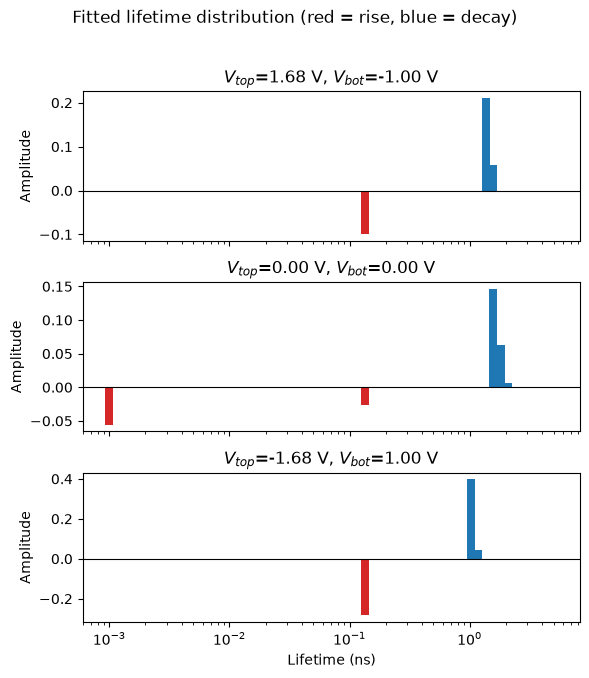

In [15]:
fig, axes = plt.subplots(scan.n_sweeps, 1, figsize=(6, 2.2 * scan.n_sweeps), sharex=True)

for ax, i, result in zip(axes, range(scan.n_sweeps), lifetime_results):
    colors = ["tab:red" if a < 0 else "tab:blue" for a in result.amplitudes]
    ax.bar(result.tau_grid, result.amplitudes, width=result.tau_grid * 0.15, color=colors)
    ax.set_xscale("log")
    ax.axhline(0, color="k", lw=0.8)
    ax.set_ylabel("Amplitude")
    ax.set_title(f"$V_{{top}}$={scan.v_top[i]:.2f} V, $V_{{bot}}$={scan.v_bot[i]:.2f} V")

axes[-1].set_xlabel("Lifetime (ns)")
fig.suptitle("Fitted lifetime distribution (red = rise, blue = decay)", y=1.02)
fig.tight_layout()

## Rise time vs. distance from the excitation spot

`right1` and `right2` get the same `fitting.fit_scan_lifetime` call as the field sweep above — same `t0`, IRF `kernel`, fit window, and `ALPHA`, so the rise times are on the same footing. Their distances from the excitation spot were already computed above (`distance_um`).

In [16]:
shifted_results = {
    name: fitting.fit_scan_lifetime(
        sweep, t0, kernel, t_range=(T_MIN_RISE_NS, T_MAX_RISE_NS), alpha=ALPHA,
    )[0]
    for name, sweep in shifted_decays.items()
}

for name, result in shifted_results.items():
    print(f"{name} (d={distance_um[name]:.2f} um):")
    print(result)
    print()

right1 (d=2.36 um):
SparseLifetimeResult
  Rise         : 0.1354 ± 0 (1 component(s))
  Decay        : 0.9769 ± 0.064 (2 component(s))
  alpha        : 0.001
  Residual std : 0.1501

right2 (d=4.37 um):
SparseLifetimeResult
  Rise         : 0.1564 ± 0 (1 component(s))
  Decay        : 2.644 ± 0.6 (7 component(s))
  alpha        : 0.001
  Residual std : 0.1388



Only two points can't distinguish a transport model — a ballistic (`t_rise = t0 + d/v`) and a diffusive (`t_rise = t0 + d²/4D`) form each have two free parameters, so both pass exactly through two points (`scipy.optimize.curve_fit` will warn that the parameter covariance can't be estimated — expected here, not a fit failure, so the warning is silenced below). The two curves are still worth plotting: they only diverge *away* from the two measured points, which is what an illustration of the two regimes is meant to show — this is not a measurement of `v` or `D`. That would need a third spot at another distance, the same way the strain-scan analysis this method was originally used for relied on five points, not two.

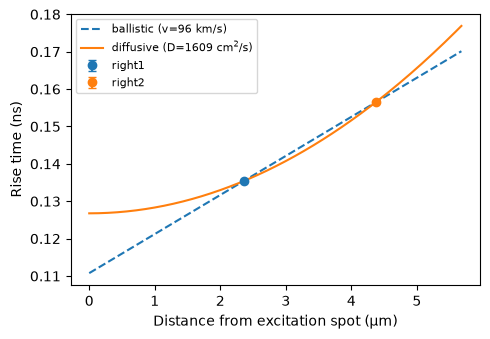

In [17]:
import warnings
from scipy.optimize import curve_fit


def ballistic(d, t0, v):
    return t0 + d / v


def diffusive(d, t0, D):
    return t0 + d ** 2 / (4 * D)


d_um = np.array([distance_um[name] for name in shifted_results])
t_rise = np.array([r.tau_rise for r in shifted_results.values()])

with warnings.catch_warnings():
    warnings.simplefilter("ignore")  # covariance is not estimable from 2 points -- see markdown above
    p_ball, _ = curve_fit(ballistic, d_um, t_rise, p0=[t_rise.min(), 20], maxfev=10000)
    p_diff, _ = curve_fit(diffusive, d_um, t_rise, p0=[t_rise.min(), 5], maxfev=10000)

d_fine = np.linspace(0, d_um.max() * 1.3, 200)

fig, ax, artists = plotting.plot_rise_time_vs_distance(
    d_um, t_rise, labels=list(shifted_results.keys()),
)
ax.plot(d_fine, ballistic(d_fine, *p_ball), "--", color="tab:blue",
        label=f"ballistic (v={p_ball[1]:.0f} km/s)")
ax.plot(d_fine, diffusive(d_fine, *p_diff), "-", color="tab:orange",
        label=f"diffusive (D={p_diff[1] * 10:.0f} cm$^2$/s)")
ax.legend(fontsize=8)
fig.tight_layout()